# Multiclass Classification
using Neural Network

MNIST 데이터셋 사용

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

import tensorflow as tf
import keras
keras.utils.set_random_seed(SEED)

## 데이터 준비

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

### EDA

#### 랜덤 확인

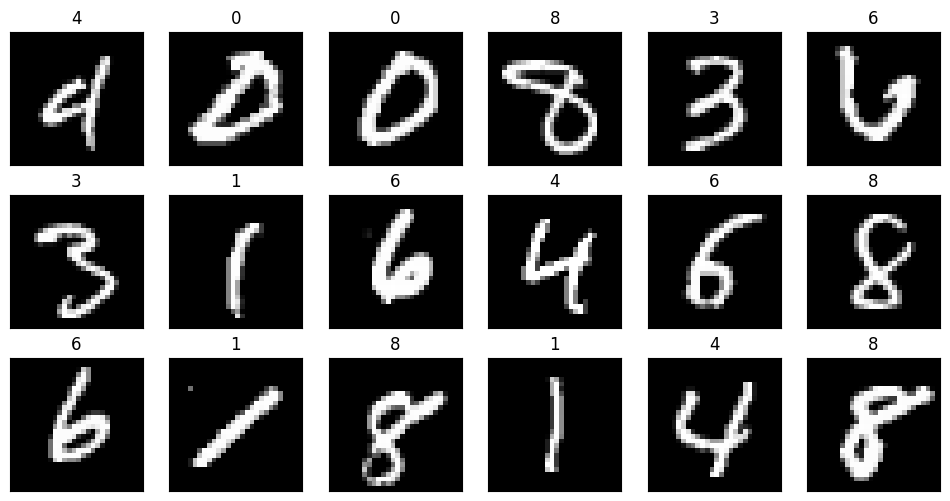

In [4]:
samples = np.random.randint(len(x_train), size=18)

plt.figure(figsize = (12, 6))
for i, idx in enumerate(samples):
    plt.subplot(3, 6, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[idx], cmap = 'gray')
    plt.title(y_train[idx].item())
plt.show()

### 데이터 분리

위에서 이미 train과 test를 따로 불러왔으니까,

train을 다시 validation과 train으로 분리

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_val, y_train, y_val = train_test_split(x_train, y_train,
                                  test_size = 0.2, random_state = SEED, shuffle=True)

In [6]:
x_train.shape, x_val.shape, y_train.shape, y_val.shape

((48000, 28, 28), (12000, 28, 28), (48000,), (12000,))

## 전처리

### Scaling (Min Max)

x만

In [7]:
x_train_s = x_train / 255.
x_val_s = x_val / 255.

### Encoding (One Hot)

y만

In [8]:
from keras.utils import to_categorical

y_train_e = to_categorical(y_train, num_classes=10)
y_val_e = to_categorical(y_val, num_classes=10)

### 이미지 1장을 2차원 행렬에서 1차원 벡터로 펴기

In [9]:
x_train_s = x_train_s.reshape(-1, 28*28)
x_val_s = x_val_s.reshape(-1, 28*28)

## 모델 정의

x_train_s = (48000, 28) 이었음

In [10]:
from keras import layers
model = keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(10, activation='softmax')
])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,818 (100.85 KB)

 Trainable params: 25,818 (100.85 KB)

 Non-trainable params: 0 (0.00 B)

## 컴파일

In [12]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 학습

In [13]:
EPOCHS = 30

history = model.fit(
    x_train_s, y_train_e,
    epochs = EPOCHS,
    batch_size = 256,
    validation_data = (x_val_s, y_val_e)
)

Epoch 1/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.7545 - loss: 0.8772 - val_accuracy: 0.9071 - val_loss: 0.3627
Epoch 2/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9153 - loss: 0.3074 - val_accuracy: 0.9244 - val_loss: 0.2640
Epoch 3/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9298 - loss: 0.2474 - val_accuracy: 0.9337 - val_loss: 0.2314
Epoch 4/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9382 - loss: 0.2170 - val_accuracy: 0.9398 - val_loss: 0.2118
Epoch 5/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9436 - loss: 0.1960 - val_accuracy: 0.9444 - val_loss: 0.1978
Epoch 6/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9485 - loss: 0.1799 - val_accuracy: 0.9464 - val_loss: 0.1866
Epoch 7/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9520 - loss: 0.1667 - val_accuracy: 0.9486 - val_loss: 0.1790
Epoch 8/30
188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9546 - loss: 0.1556 - val_accuracy:

### 학습 결과 그래프

In [14]:
def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure(figsize=(16,8))

  plt.subplot(1,2,1)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
  plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')
  plt.legend()

  plt.subplot(1,2,2)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
  plt.plot(hist['epoch'], hist['val_accuracy'], label = 'Val Accuracy')

  plt.legend()
  plt.show()

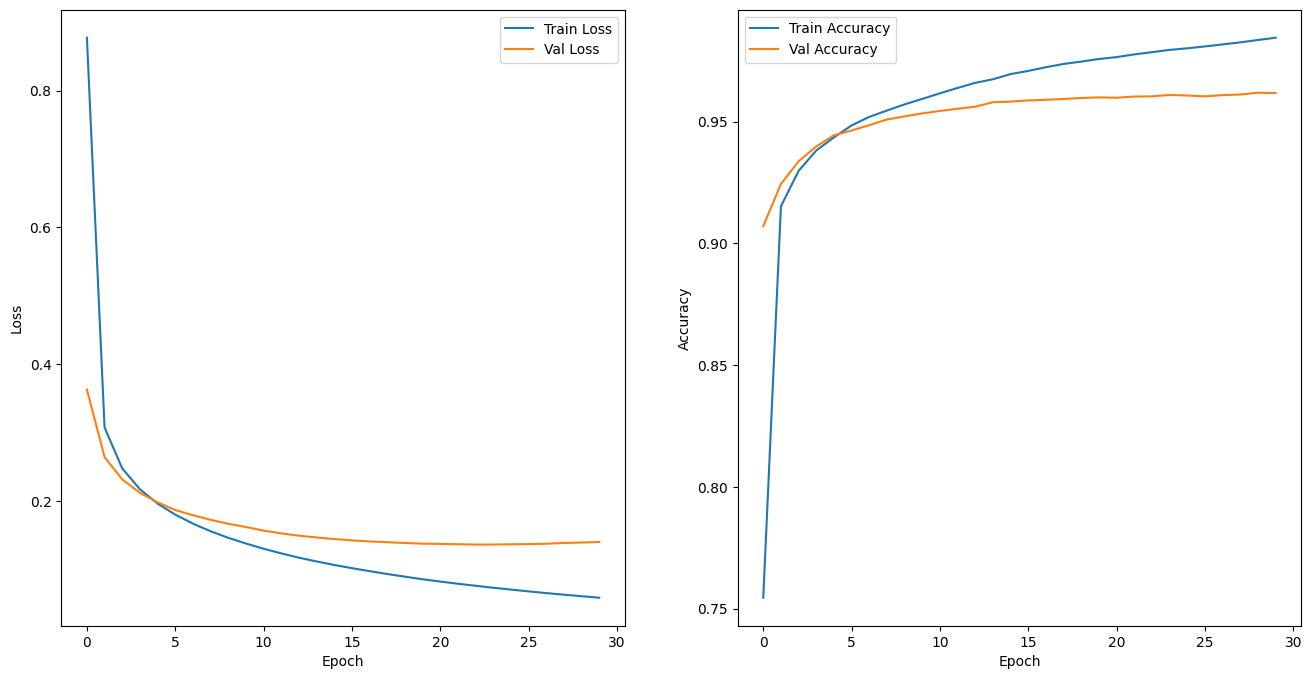

In [15]:
plot_history(history)

## 테스트

### x scaling만 하고, y encoding은 생략

In [16]:
x_test_s = x_test / 255.

In [17]:
x_test_s = x_test_s.reshape(-1, 28*28)

### 돌려보기

In [18]:
y_pred = model.predict(x_test_s)
y_pred[:10]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[5.34786413e-05, 1.86857534e-08, 4.74629342e-05, 5.23744209e-04,
        1.47174972e-09, 6.93171032e-08, 1.74714310e-16, 9.99335587e-01,
        6.29734586e-07, 3.90445093e-05],
       [5.04085174e-09, 1.49111741e-03, 9.98508811e-01, 4.40679271e-09,
        4.74841323e-16, 2.43772691e-09, 6.35220487e-11, 3.37966796e-13,
        6.19560137e-09, 5.64810958e-18],
       [1.69800592e-06, 9.98258770e-01, 2.28253102e-05, 2.26602424e-06,
        3.54703428e-04, 4.39780597e-05, 1.47880007e-06, 1.09904166e-03,
        1.96557274e-04, 1.85864592e-05],
       [9.99773264e-01, 3.09999639e-12, 2.17745415e-04, 1.60136167e-07,
        3.75149511e-09, 2.34418138e-08, 8.78368064e-06, 1.65806213e-08,
        7.16320059e-10, 2.66904276e-08],
       [1.96870974e-06, 1.18879534e-07, 2.99927535e-07, 1.70425480e-07,
        9.94278073e-01, 2.30114911e-05, 3.09815914e-05, 3.03272191e-06,
        2.88384831e-06, 5.65943634e-03],
       [4.27318270e-08, 9.98664856e-01, 4.26142009e-07, 9.16124350e-08,
   

각 리스트 안에서 확률값이 가장 높은 애의 인덱스가 정답.

7, 2, 1, 0, ....

In [19]:
y_pred = np.argmax(y_pred, axis=1)
y_pred[:10]

array([7, 2, 1, 0, 4, 1, 4, 9, 6, 9])

## 결과확인

In [20]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import confusion_matrix

def print_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)    # 맞힌 개수 / 전체 개수
    print(f"1. Accuracy: {acc:.4f}")

    re = recall_score(y_true, y_pred, average='macro')     # TP / (TP + FN)
    print(f"2. Recall: {re:.4f}")

    pr = precision_score(y_true, y_pred, average='macro')    # TP / (TP + FP)
    print(f"3. Precision: {pr:.4f}")

    f1 = f1_score(y_true, y_pred, average='macro')       # (2 * Precision * Recall) / (Precision + Recall)
    print(f"4. F1 Score: {f1:.4f}")

    # (정답, 예측값) 순서대로 지정한다!!!
    cfm = confusion_matrix(y_true, y_pred)
    s = sns.heatmap(cfm, annot=True, cmap='Blues', fmt='d', cbar=False)
    s.set(xlabel='Prediction', ylabel='Actual')
    plt.show()

1. Accuracy: 0.9630
2. Recall: 0.9625
3. Precision: 0.9628
4. F1 Score: 0.9626


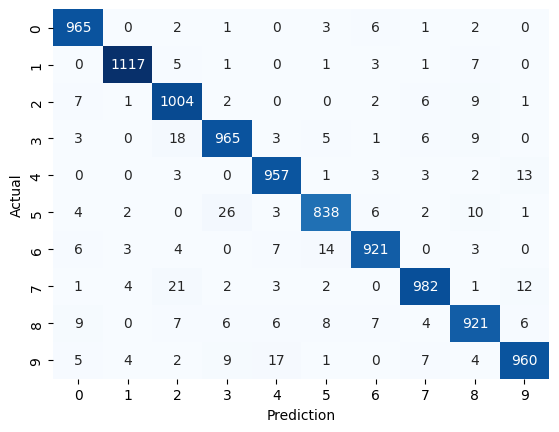

In [21]:
print_metrics(y_test, y_pred)